# Black–Scholes & the Greeks

**pyportfolios.com tutorial T02** · QQQ options, Jan 2018 – Dec 2024 · NumPy · SciPy · Matplotlib

Black–Scholes is the pricing engine of the listed-options market — not because anyone
believes its assumptions, but because it is the *coordinate system* the market quotes in.
In this notebook we

1. compute trailing 1y realized volatility for QQQ (Invesco's Nasdaq-100 ETF),
2. implement the Black–Scholes price and **all five Greeks** from scratch,
3. price calls and puts across the strike ladder and check put–call parity,
4. read the Greeks as a hedging dashboard (delta/gamma across strikes, vega/theta across maturities),
5. invert the formula — implied volatility, the number the market actually trades.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq

plt.rcParams["figure.figsize"] = (10, 5)
RF = 0.04          # flat risk-free rate for the whole notebook

## 1 · Volatility from the tape

Black–Scholes needs one non-observable input: σ. With no option chain in hand we use the
*trailing 252-day realized vol* of QQQ — the classic first estimate a desk reaches for.
We download from 2017 so the rolling window is full from January 2018.

spot = 507.45   trailing vol = 18.0%


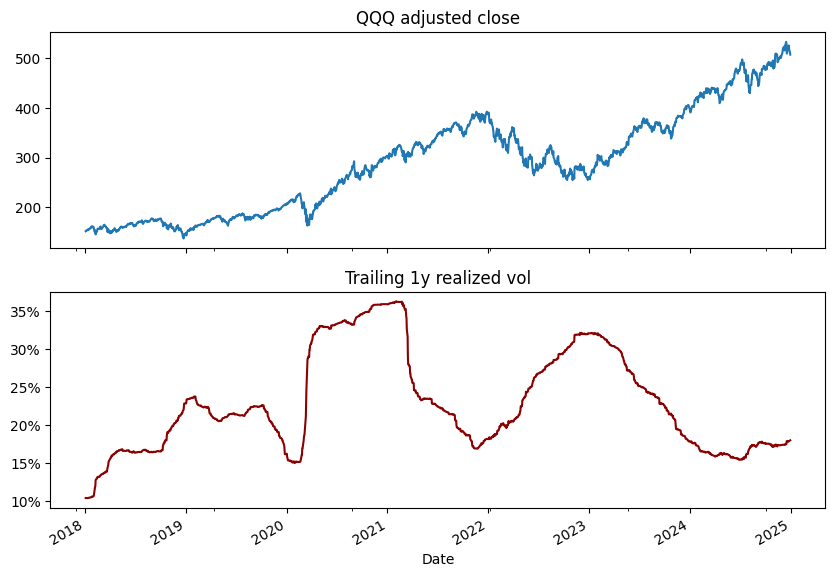

In [2]:
px = yf.download("QQQ", start="2017-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"].squeeze().dropna()
logret = np.log(px / px.shift(1)).dropna()

vol = (logret.rolling(252).std(ddof=1) * np.sqrt(252)).loc["2018-01-01":].dropna()
px = px.loc[vol.index]

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 7))
px.plot(ax=ax[0], title="QQQ adjusted close")
vol.plot(ax=ax[1], title="Trailing 1y realized vol", color="darkred")
ax[1].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}");

s0, sigma = float(px.iloc[-1]), float(vol.iloc[-1])
print(f"spot = {s0:.2f}   trailing vol = {sigma:.1%}")

## 2 · The pricing engine

Everything funnels through the two standardized distances
$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt T}$, $d_2 = d_1 - \sigma\sqrt T$.
The Greeks are the analytic partial derivatives — no finite differences, no loops,
and every function is NumPy-vectorized over strikes and maturities.

In [3]:
def d1_d2(s, k, t, rf, sigma):
    d1 = (np.log(s / k) + (rf + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
    return d1, d1 - sigma * np.sqrt(t)

def bs_price(s, k, t, rf, sigma, kind="call"):
    d1, d2 = d1_d2(s, k, t, rf, sigma)
    if kind == "call":
        return s * norm.cdf(d1) - k * np.exp(-rf * t) * norm.cdf(d2)
    return k * np.exp(-rf * t) * norm.cdf(-d2) - s * norm.cdf(-d1)

def bs_greeks(s, k, t, rf, sigma, kind="call"):
    """delta, gamma, vega (per 1.00 vol), theta (per year), rho (per 1.00 rate)."""
    d1, d2 = d1_d2(s, k, t, rf, sigma)
    pdf = norm.pdf(d1)
    delta = norm.cdf(d1) if kind == "call" else norm.cdf(d1) - 1.0
    gamma = pdf / (s * sigma * np.sqrt(t))
    vega  = s * pdf * np.sqrt(t)
    if kind == "call":
        theta = -s * pdf * sigma / (2 * np.sqrt(t)) - rf * k * np.exp(-rf * t) * norm.cdf(d2)
        rho   =  k * t * np.exp(-rf * t) * norm.cdf(d2)
    else:
        theta = -s * pdf * sigma / (2 * np.sqrt(t)) + rf * k * np.exp(-rf * t) * norm.cdf(-d2)
        rho   = -k * t * np.exp(-rf * t) * norm.cdf(-d2)
    return delta, gamma, vega, theta, rho

## 3 · The strike ladder & put–call parity

Price 1y calls and puts across moneyness 0.7–1.3 at today's spot and vol. The parity
identity $C - P = S - Ke^{-rT}$ holds to machine precision — if it doesn't, the
implementation is wrong. It is the cheapest unit test in quantitative finance.

max |C - P - (S - K e^-rT)| = 8.53e-14   (machine precision)


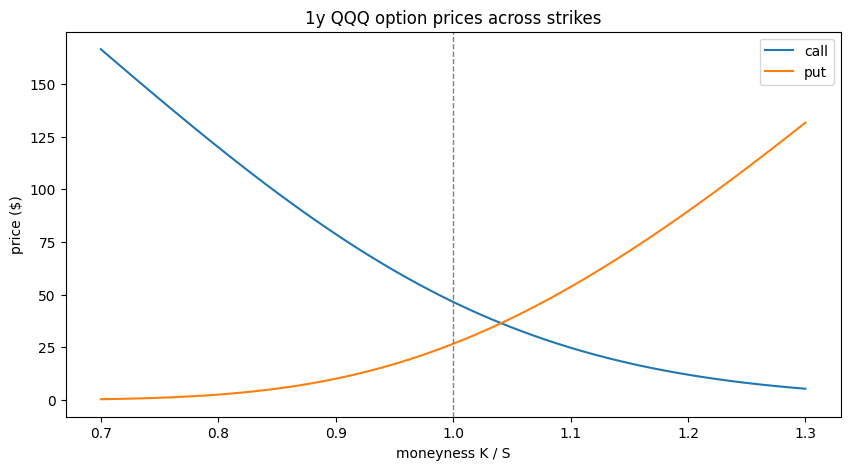

In [4]:
T = 1.0
m = np.linspace(0.7, 1.3, 61)
K = m * s0
calls, puts = bs_price(s0, K, T, RF, sigma, "call"), bs_price(s0, K, T, RF, sigma, "put")

plt.plot(m, calls, label="call"); plt.plot(m, puts, label="put")
plt.axvline(1.0, ls="--", lw=1, color="grey")
plt.xlabel("moneyness K / S"); plt.ylabel("price ($)")
plt.legend(); plt.title("1y QQQ option prices across strikes");

gap = np.abs((calls - puts) - (s0 - K * np.exp(-RF * T))).max()
print(f"max |C - P - (S - K e^-rT)| = {gap:.2e}   (machine precision)")

## 4 · The Greeks as a hedging dashboard

**Delta** is the hedge ratio and a rough moneyness gauge; **gamma** is how fast that hedge
goes stale — it peaks near the money, which is where hedging costs live. For the ATM 1y
call we print the full dashboard a desk would quote.

ATM 1y call     =    46.57
delta           =   0.6225   (shares to short per call)
gamma           = 0.004152   (delta drift per $1 spot move)
vega / vol pt   =    1.928   ($ per 1 vol point)
theta / day     =  -0.0772   ($ decay per calendar day)
rho / rate pt   =    2.693   ($ per 1% rate move)


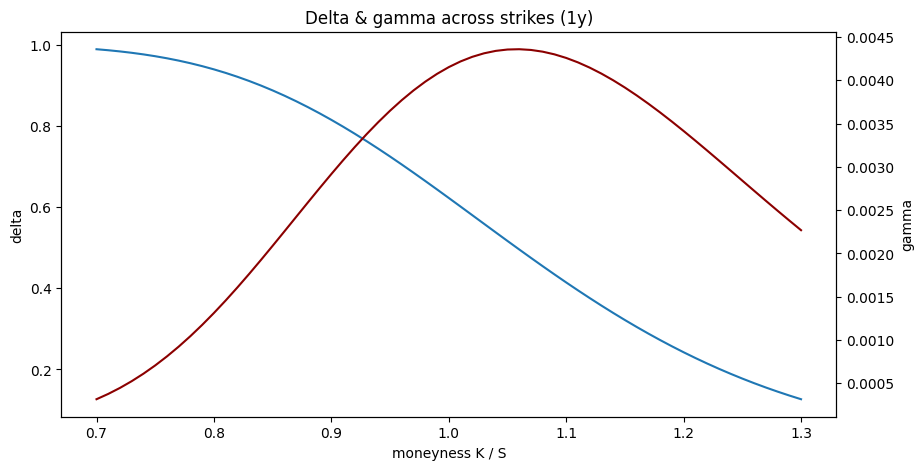

In [5]:
delta, gamma_, vega, theta, rho = bs_greeks(s0, K, T, RF, sigma, "call")

fig, ax1 = plt.subplots()
ax1.plot(m, delta, label="delta")
ax2 = ax1.twinx()
ax2.plot(m, gamma_, color="darkred", label="gamma")
ax1.set_xlabel("moneyness K / S"); ax1.set_ylabel("delta"); ax2.set_ylabel("gamma")
ax1.set_title("Delta & gamma across strikes (1y)");

d0, g0, v0, t0, r0 = bs_greeks(s0, s0, T, RF, sigma, "call")
c0 = bs_price(s0, s0, T, RF, sigma, "call")
print(f"ATM 1y call     = {c0:8.2f}")
print(f"delta           = {d0:8.4f}   (shares to short per call)")
print(f"gamma           = {g0:8.6f}   (delta drift per $1 spot move)")
print(f"vega / vol pt   = {v0/100:8.3f}   ($ per 1 vol point)")
print(f"theta / day     = {t0/365:8.4f}   ($ decay per calendar day)")
print(f"rho / rate pt   = {r0/100:8.3f}   ($ per 1% rate move)")

## 5 · Vega and theta across maturities

For the ATM strike, vega grows like $\sqrt T$ — long-dated options are volatility
instruments — while per-day theta explodes as expiry approaches: the shorter the option,
the faster the clock. This trade-off *is* the term-structure decision every options
book makes.

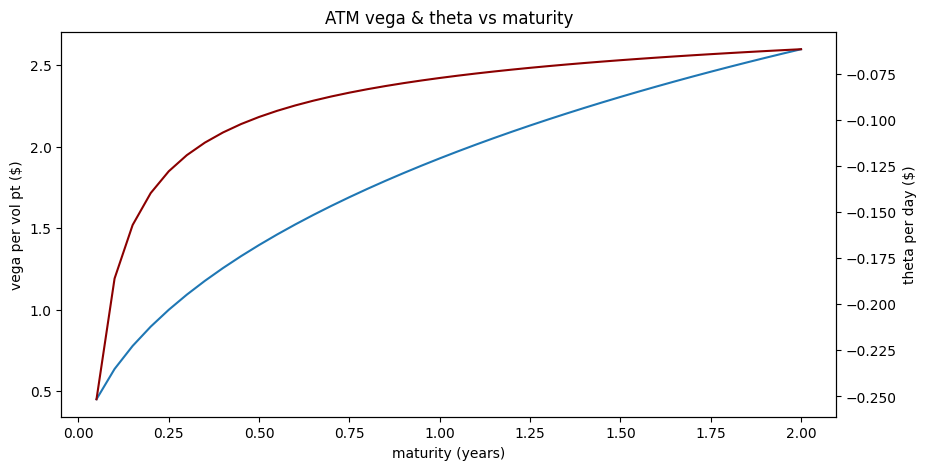

In [6]:
mats = np.linspace(0.05, 2.0, 40)
_, _, vega_t, theta_t, _ = bs_greeks(s0, s0, mats, RF, sigma, "call")

fig, ax1 = plt.subplots()
ax1.plot(mats, vega_t / 100, label="vega / vol pt")
ax2 = ax1.twinx()
ax2.plot(mats, theta_t / 365, color="darkred", label="theta / day")
ax1.set_xlabel("maturity (years)"); ax1.set_ylabel("vega per vol pt ($)")
ax2.set_ylabel("theta per day ($)")
ax1.set_title("ATM vega & theta vs maturity");

## 6 · Implied volatility — the market's language

Nobody quotes option prices in dollars on a trading desk; they quote the σ that makes
Black–Scholes reproduce the dollar price. Inverting the formula is a 1-D root-finding
problem (the price is monotonic in σ, so Brent's method is bulletproof). The round trip
recovers our input vol to 10 decimal places.

In [7]:
def implied_vol(price, s, k, t, rf, kind="call"):
    return brentq(lambda sig: bs_price(s, k, t, rf, sig, kind) - price, 1e-4, 5.0,
                  xtol=1e-10)

c0 = bs_price(s0, s0, T, RF, sigma, "call")
iv = implied_vol(c0, s0, s0, T, RF)
print(f"input sigma     = {sigma:.10f}")
print(f"recovered sigma = {iv:.10f}")

# the vega check: +1 vol pt should move the price by ~vega/100
c_up = bs_price(s0, s0, T, RF, sigma + 0.01, "call")
_, _, v0, _, _ = bs_greeks(s0, s0, T, RF, sigma, "call")
print(f"price(+1 vol pt) - price = {c_up - c0:.3f}   vs vega/100 = {v0/100:.3f}")

input sigma     = 0.1803523378
recovered sigma = 0.1803523378
price(+1 vol pt) - price = 1.930   vs vega/100 = 1.928


## Takeaways

- Five NumPy lines price the option; five more give the entire Greek dashboard analytically.
- Put–call parity holds to machine precision — always run this test before trusting a pricer.
- Delta is the hedge, gamma the hedge's decay, vega the vol exposure, theta the rent you
  pay for gamma, rho the (usually ignorable) rate leg.
- Implied vol is Black–Scholes read backwards — the formula survives as the market's
  quoting convention, not as a model anyone believes.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*